In [1]:
!pip install numpy
!pip install torch
!pip install -q tqdm
!pip install matplotlib

In [1]:
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self, layers=None):
        super().__init__()
        if layers is None:
            layers = [2, 50, 50, 50, 50, 2]
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            inputs = self.activation(layer(inputs))

        return self.layers[-1](inputs)[:, 0], self.layers[-1](inputs)[:, 1]

In [3]:
def compute_schrodinger_equation_residue(model, x, t, m, hbar):
    psiR, psiI = model(x, t)

    psiR_t = torch.autograd.grad(psiR, t, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiI_t = torch.autograd.grad(psiI, t, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]

    psiR_x = torch.autograd.grad(psiR, x, torch.ones_like(psiR), create_graph=True, retain_graph=True)[0]
    psiR_xx = torch.autograd.grad(psiR_x, x, torch.ones_like(psiR_x), create_graph=True, retain_graph=True)[0]
    psiI_x = torch.autograd.grad(psiI, x, torch.ones_like(psiI), create_graph=True, retain_graph=True)[0]
    psiI_xx = torch.autograd.grad(psiI_x, x, torch.ones_like(psiI_x), create_graph=True, retain_graph=True)[0]

    residue_0 = -0.5*hbar*hbar/m * psiR_xx + hbar * psiI_t
    residue_1 = -0.5*hbar*hbar/m * psiI_xx - hbar * psiR_t
    return torch.square(residue_0).mean(), torch.square(residue_1).mean()

In [4]:
def analytical_solution(x, t, A, hbar, m, L):
    psi = A * np.sin(np.pi*x/L) * np.exp(-0.5*L*L*hbar/m*t*1.j)
    return np.real(psi), np.imag(psi)

In [5]:
device = torch.device("cuda")

In [6]:
n_colloc, n_bc = 5000, 200
epochs = 5000
hbar = 1.
m = 1.
L = 1.

In [ ]:
torch.Tensor(torch.rand(n_colloc, 1)*4, )

tensor([[2.4528],
        [1.9861],
        [2.1135],
        ...,
        [0.8155],
        [3.0628],
        [3.2452]])

In [37]:
x_colloc = torch.rand(n_colloc, 1, requires_grad=True).to(device)
t_colloc = torch.Tensor(4*np.pi*torch.rand(n_colloc, 1)).to(device)
t_colloc.requires_grad_()

# initial condition
x_ic = torch.rand(n_bc, 1).to(device)
t_ic = torch.zeros(n_bc, 1).to(device)
psiR_ic, psiI_ic = analytical_solution(x_ic.cpu().numpy(), t_ic.cpu().numpy(), 1., 1., 1., 1.)
psiR_ic = torch.FloatTensor(psiR_ic).to(device)
psiI_ic = torch.FloatTensor(psiI_ic).to(device)

# boundary conditions
x_bc = torch.cat([torch.zeros(n_bc // 2, 1), torch.ones(n_bc // 2, 1) * L]).to(device)
t_bc = torch.rand(n_bc, 1).to(device)
psiR_bc, psiI_bc = torch.zeros(n_bc, 1).to(device), torch.zeros(n_bc, 1).to(device)

In [38]:
pinn = PINN().to(device)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

In [39]:
losses_pde_R = []
losses_pde_I = []
losses_ic_R = []
losses_ic_I = []
losses_bc_R = []
losses_bc_I = []
losses = []

In [40]:
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()

    loss_pde_R, loss_pde_I = compute_schrodinger_equation_residue(pinn, x_colloc, t_colloc, 1., 1.)
    pinn_ic_R, pinn_ic_I = pinn(x_ic, t_ic)
    loss_ic_R = nn.functional.mse_loss(pinn_ic_R.flatten()[:, None], psiR_ic)
    loss_ic_I = nn.functional.mse_loss(pinn_ic_I.flatten()[:, None], psiI_ic)
    pinn_bc_R, pinn_bc_I = pinn(x_bc, t_bc)
    loss_bc_R = nn.functional.mse_loss(pinn_bc_R.flatten()[:, None], psiR_bc)
    loss_bc_I = nn.functional.mse_loss(pinn_bc_I.flatten()[:, None], psiI_bc)

    loss = loss_pde_R + loss_pde_I + 10 * loss_ic_R + 10 * loss_ic_I + 10 * loss_bc_R + 10 * loss_bc_I

    loss.backward()
    optimizer.step()

    losses_pde_R.append(loss_pde_R.item())
    losses_pde_I.append(loss_pde_I.item())
    losses_ic_R.append(loss_ic_R.item())
    losses_ic_I.append(loss_ic_I.item())
    losses_bc_R.append(loss_bc_R.item())
    losses_bc_I.append(loss_bc_I.item())
    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch}: {loss.item():.2f}")

 11%|█         | 527/5000 [00:02<00:19, 230.53it/s]

Epoch 499: 0.07


 21%|██        | 1031/5000 [00:04<00:17, 230.29it/s]

Epoch 999: 0.04


 31%|███       | 1535/5000 [00:06<00:15, 228.82it/s]

...

Epoch 3999: 0.01


 91%|█████████ | 4530/5000 [00:19<00:02, 231.28it/s]

Epoch 4499: 0.00


100%|██████████| 5000/5000 [00:21<00:00, 230.57it/s]

Epoch 4999: 0.00


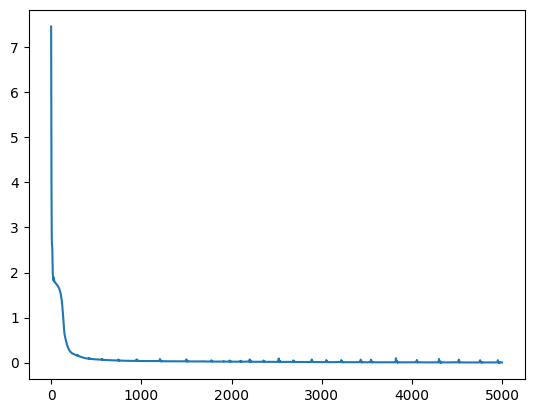

In [41]:
plt.plot(range(epochs), losses)

In [42]:
with torch.no_grad():
    x_test = torch.linspace(0., 1., 100).flatten()[:, None].to(device)
    psi = pinn(x_test, 0.1*torch.ones(100).flatten()[:, None].to(device))

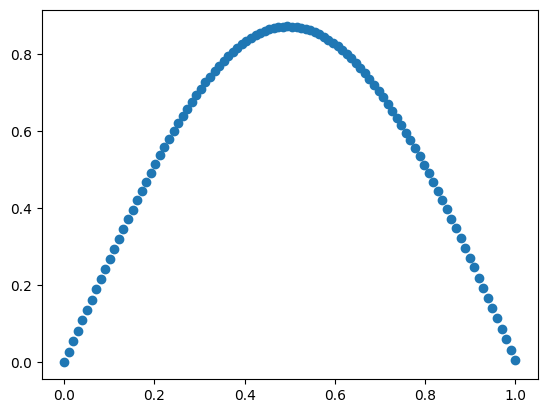

In [43]:
plt.scatter(x_test.cpu().numpy(), psi[0].cpu().numpy())

In [44]:
with torch.no_grad():
    t_test = torch.linspace(0, 4*torch.pi, 100).to(device).flatten()[:, None]
    x_test = torch.ones(100).to(device).flatten()[:, None] * 0.5
    psi = pinn(x_test, t_test)

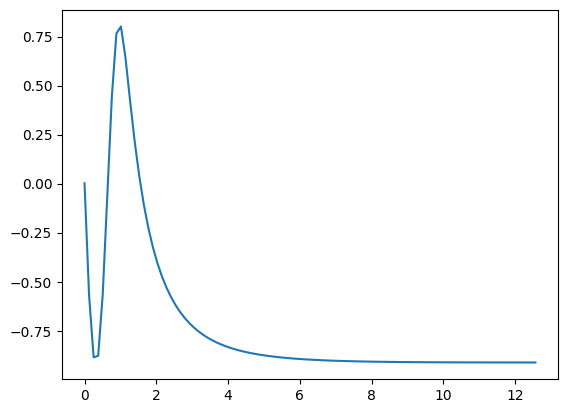

In [45]:
plt.plot(t_test.cpu().numpy(), psi[1].cpu().numpy())